In [ ]:
import matplotlib.pylab as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import networkx as nx

In [3]:
icon_grid = xr.open_dataset("grid.nc")
icon_grid['cell'] = icon_grid.cell.values
pred = xr.open_dataset("../evals/rain_mse.zarr", engine="zarr")
pred_single_time_and_var = pred.isel(start_time=0, elapsed_forecast_duration=0).sel(state_feature='t_2m')
pred_single_time_and_var = pred_single_time_and_var.rename({'grid_index': 'cell'})
grid_sel = icon_grid.sel(cell=pred_single_time_and_var.cell)

In [4]:
grid_sel

<xarray.Dataset> Size: 5GB
Dimensions:                        (nc: 2, edge: 17693237, vertex: 5901162,
                                    cell: 524288, ne: 6, nv: 3, no: 4,
                                    max_chdom: 1, cell_grf: 14, edge_grf: 24,
                                    vert_grf: 13)
Coordinates:
  * cell                           (cell) int64 4MB 11255161 ... 3934314
    clat                           (cell) float64 4MB ...
    clon                           (cell) float64 4MB ...
    elat                           (edge) float64 142MB ...
    elon                           (edge) float64 142MB ...
    vlat                           (vertex) float64 47MB ...
    vlon                           (vertex) float64 47MB ...
    elapsed_forecast_duration      timedelta64[ns] 8B 00:10:00
    start_time                     datetime64[ns] 8B 2020-02-12T00:50:00
    state_feature                  <U13 52B 't_2m'
    time                           datetime64[ns] 8B ...
Dimensions without coordinates: nc, edge, vertex, ne, nv, no, max_chdom,
                                cell_grf, edge_grf, vert_grf
Data variables: (12/51)
    adjacent_cell_of_edge          (nc, edge) int32 142MB ...
    cartesian_x_vertices           (vertex) float64 47MB ...
    cartesian_y_vertices           (vertex) float64 47MB ...
    cartesian_z_vertices           (vertex) float64 47MB ...
    cell_area                      (cell) float64 4MB ...
    cell_area_p                    (cell) float64 4MB ...
    ...                             ...
    vertex_of_cell                 (nv, cell) int32 6MB ...
    vertices_of_vertex             (ne, vertex) int32 142MB ...
    vlat_vertices                  (vertex, ne) float64 283MB ...
    vlon_vertices                  (vertex, ne) float64 283MB ...
    zonal_normal_dual_edge         (edge) float64 142MB ...
    zonal_normal_primal_edge       (edge) float64 142MB ...
Attributes: (12/18)
    ICON_grid_file_uri:   
    centre:               78
    crs_id:               urn:ogc:def:cs:EPSG:6.0:6422
    crs_name:             Spherical 2D Coordinate System
    ellipsoid_name:       Sphere
    global_grid:          0
    ...                   ...
    semi_major_axis:      6371229.0
    source:               svn://xceh.dwd.de/for0adm/SVN_icontools/tags/iconto...
    subcentre:            255
    title:                ICON grid description
    uuidOfHGrid:          3c7523ba-f78c-c23e-6654-012805ba3300
    uuidOfParHGrid:       6b59890b-99f3-939b-e76a-0a3ad2e43140

In [ ]:

# Pick a small lat/lon bounding box around the median location for a quick example.
clat = grid_sel["clat"].values
clon = grid_sel["clon"].values
is_rad = np.nanmax(np.abs(clat)) <= 3.2
clat_deg = np.degrees(clat) if is_rad else clat
clon_deg = np.degrees(clon) if is_rad else clon
clon_deg = ((clon_deg + 180.0) % 360.0) - 180.0

center_lat = float(np.nanmedian(clat_deg))
center_lon = float(np.nanmedian(clon_deg))
delta_deg = 0.5
bbox = {
    "lat_min": center_lat - delta_deg,
    "lat_max": center_lat + delta_deg,
    "lon_min": center_lon - delta_deg,
    "lon_max": center_lon + delta_deg,
}

mask = (
    (clat_deg >= bbox["lat_min"])
    & (clat_deg <= bbox["lat_max"])
    & (clon_deg >= bbox["lon_min"])
    & (clon_deg <= bbox["lon_max"])
)

subset_cells = np.where(mask)[0]
# max_cells = 2000
# if subset_cells.size > max_cells:
#     subset_cells = subset_cells[:max_cells]

grid_sub = grid_sel.isel(cell=subset_cells)
subset_cells.size

124419

In [ ]:
def show_grid(voc, clat, clon, vlat, vlon, title=None, ax=None, marker='.'):
    # ax.set_global()
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor="black")

    plt.plot(np.rad2deg(clon), np.rad2deg(clat), transform=ccrs.Geodetic())
    plt.scatter(
        np.rad2deg(clon),
        np.rad2deg(clat),
        c=np.arange(len(clon)),
        s=15,
        zorder=10,
        cmap="turbo",
        transform=ccrs.Geodetic(),
        marker=marker
    )
    plt.scatter(
        np.rad2deg(clon)[0],
        np.rad2deg(clat)[0],
        c='grey',
        s=30,
        zorder=10,
        transform=ccrs.Geodetic(),
    )
    for v1, v2, v3 in voc.T - 1:
        i = np.array([v1, v2, v3, v1])
        plt.plot(
            np.rad2deg(vlon[i]),
            np.rad2deg(vlat[i]),
            c="k",
            lw=1,
            alpha=0.1,
            transform=ccrs.Geodetic(),
        )
    if title is not None:
        ax.set_title(title)

In [5]:
sg1 = grid_sel.isel(cell=slice(4* 2 ** (2 * 4)))

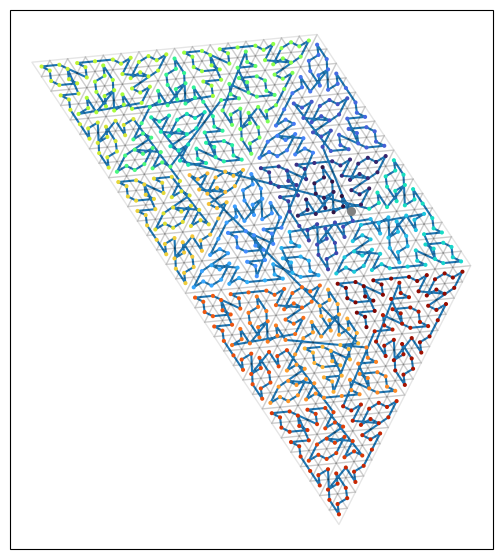

In [ ]:
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(-60, 0))
show_grid(
    sg1.vertex_of_cell.values,
    sg1.clat.values,
    sg1.clon.values,
    grid_sel.vlat.values,
    grid_sel.vlon.values,
    ax=ax
)

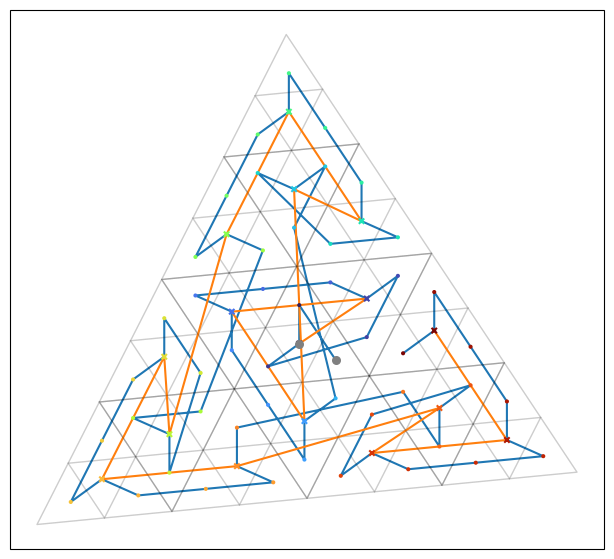

In [26]:
def coarsen_vertex_of_cell(voc):
    return voc.reshape(3, -1, 4)[[0,1,2],:,[0,1,3]]

def coarsen_cell_center(cvalue, offset=2):
    return cvalue[..., offset::4]

voc = sg1.vertex_of_cell.values
clat = sg1.clat.values
clon = sg1.clon.values
offset = 2

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(-60, 0))
for i in range(2):
    voc = coarsen_vertex_of_cell(voc)
    clat = coarsen_cell_center(clat, offset)
    clon = coarsen_cell_center(clon, offset)
    if i == 1:
        marker = 'x'
    else:
        marker = '.'
    show_grid(voc, clat, clon, grid_sel.vlat.values, grid_sel.vlon.values, ax=ax, marker=marker)

In [ ]:
sg1.cell.values[::4]

In [ ]:
coarse_cells = sg1.cell.values[2::4]
coarse_triangles = coarse_cells.reshape(-1,4)

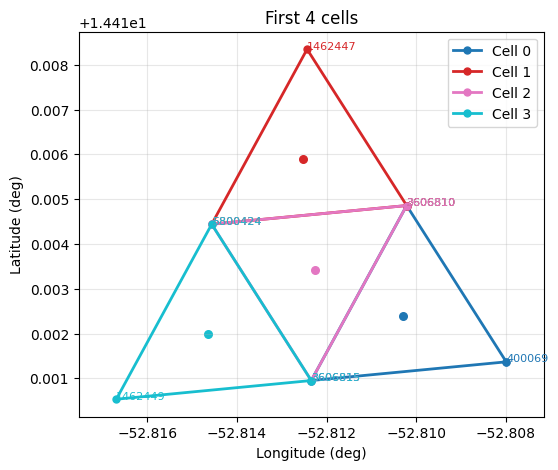

In [162]:
# Plot the first four cells' vertices on a single lon/lat figure.
n_cells = 4
colors = plt.cm.tab10(np.linspace(0, 1, n_cells))

plt.figure(figsize=(6, 5))
for idx in range(n_cells):
    cell_vertices = sg1.vertex_of_cell.values[:, idx] - 1
    triangle_idx = np.r_[cell_vertices, cell_vertices[0]]
    tri_lon = np.rad2deg(grid_sel.vlon.values[triangle_idx])
    tri_lat = np.rad2deg(grid_sel.vlat.values[triangle_idx])
    plt.plot(tri_lon, tri_lat, "-o", lw=2, ms=5, color=colors[idx], label=f"Cell {idx}")
    plt.scatter(
        np.rad2deg(sg1.clon.values[idx]),
        np.rad2deg(sg1.clat.values[idx]),
        c=[colors[idx]],
        s=30,
    )
    for v_idx, lon, lat in zip(cell_vertices, tri_lon[:-1], tri_lat[:-1]):
        plt.text(lon, lat, str(int(v_idx) + 1), fontsize=8, color=colors[idx])

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("First 4 cells")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.show()

In [93]:
cell = grid_sel.cell.values
cell = coarsen_cell_center(cell)
values = pred_single_time_and_var.isel(cell=cell).values()

In [113]:
voc = grid_sel.vertex_of_cell.values
clat = grid_sel.clat.values
clon = grid_sel.clon.values
for i in range(2):
    print(i)
    # voc = coarsen_vertex_of_cell(voc)
    clat = coarsen_cell_center(clat)
    clon = coarsen_cell_center(clon)
    cell = coarsen_cell_center(cell)

0
1


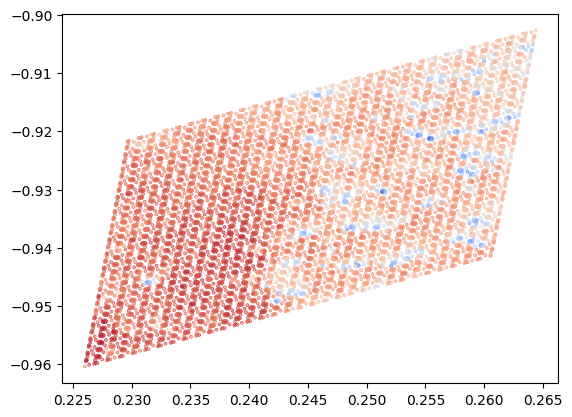

In [115]:
values = pred_single_time_and_var.isel(cell=cell).state.values
scatter = plt.scatter(grid_sel.clat.isel(cell=cell).values, grid_sel.clon.isel(cell=cell).values, c=values, s=0.5, cmap='coolwarm', 
                    vmin=min(values), vmax=max(values), 
                    alpha=0.8, linewidths=2)

In [116]:
len(values)

8192

In [6]:
coarsen=1
mean = pred_single_time_and_var.state.values.reshape(-1, 4**coarsen).mean(axis=-1)

cell = grid_sel.cell
cell = cell[::4**coarsen]
n = grid_sel.neighbor_cell_index.values.reshape(-1, 4**coarsen)

In [7]:
n.shape

(393216, 4)

In [11]:
# Second coarsening


# Create a graph from overlapping sets
G = nx.Graph()
Gorg = nx.Graph()
Gcoarser = nx.Graph()
Gcoarsest = nx.Graph()
Gcoarsestx = nx.Graph()


### First coarsening
coarse_cells = sg1.cell.values[2::4]
coarse_triangles = coarse_cells.reshape(-1,4)

# Add nodes with positions based on clat and clon
pos = {}
for cell in coarse_triangles.flatten():
    G.add_node(cell)
    clat = np.rad2deg(icon_grid.sel(cell=cell).clat.values)
    clon = np.rad2deg(icon_grid.sel(cell=cell).clon.values)
    pos[cell] = (clon, clat)  # (x, y) -> (longitude, latitude)

# Add edges between overlapping cells
for cell1, cell2, cell3, cell4 in coarse_triangles:
    G.add_edge(cell3, cell1)
    G.add_edge(cell3, cell2)
    G.add_edge(cell3, cell4)


### Original layer (finest)
orig_pos = {}
for cell in sg1.cell.values:
    Gorg.add_node(cell)
    clat = np.rad2deg(icon_grid.sel(cell=cell).clat.values)
    clon = np.rad2deg(icon_grid.sel(cell=cell).clon.values)
    orig_pos[cell] = (clon, clat)

orig_cells = set({})
for cell1, cell2, cell3, cell4 in coarse_triangles:
    for cell in [cell1, cell2, cell3, cell4]:
        for n in sg1.sel(cell=cell).neighbor_cell_index.values-1:
            if n in sg1.cell.values and n != cell:
                Gorg.add_edge(cell, n)


### Next coarser
coarser_cells = coarse_cells[2::4]
coarser_triangles = coarser_cells.reshape(-1,4)

pos_coarser = {}
for cell in coarser_triangles.flatten():
    Gcoarser.add_node(cell)
    clat = np.rad2deg(icon_grid.sel(cell=cell).clat.values)
    clon = np.rad2deg(icon_grid.sel(cell=cell).clon.values)
    pos_coarser[cell] = (clon, clat)  # (x, y) -> (longitude, latitude)

for cell1, cell2, cell3, cell4 in coarser_triangles:
    Gcoarser.add_edge(cell1, cell2)
    Gcoarser.add_edge(cell1, cell3)
    Gcoarser.add_edge(cell1, cell4)

### Next coarser
coarser_cells = coarser_cells[::4]
coarsest_triangles = coarser_cells.reshape(-1,4)

pos_coarsest = {}
for cell in coarsest_triangles.flatten():
    Gcoarsest.add_node(cell)
    clat = np.rad2deg(icon_grid.sel(cell=cell).clat.values)
    clon = np.rad2deg(icon_grid.sel(cell=cell).clon.values)
    pos_coarsest[cell] = (clon, clat)  # (x, y) -> (longitude, latitude)

for cell1, cell2, cell3, cell4 in coarsest_triangles:
    Gcoarsest.add_edge(cell1, cell2)
    Gcoarsest.add_edge(cell1, cell3)
    Gcoarsest.add_edge(cell1, cell4)

### Next coarser
coarser_cells = coarser_cells[::4]
coarsest_triangles = coarser_cells.reshape(-1,4)

pos_coarsestx = {}
for cell in coarsest_triangles.flatten():
    Gcoarsestx.add_node(cell)
    clat = np.rad2deg(icon_grid.sel(cell=cell).clat.values)
    clon = np.rad2deg(icon_grid.sel(cell=cell).clon.values)
    pos_coarsestx[cell] = (clon, clat)  # (x, y) -> (longitude, latitude)

for cell1, cell2, cell3, cell4 in coarsest_triangles:
    Gcoarsestx.add_edge(cell1, cell2)
    Gcoarsestx.add_edge(cell1, cell3)
    Gcoarsestx.add_edge(cell1, cell4)


print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Number of connected components: {nx.number_connected_components(G)}")

Graph created with 256 nodes and 192 edges
Number of connected components: 64


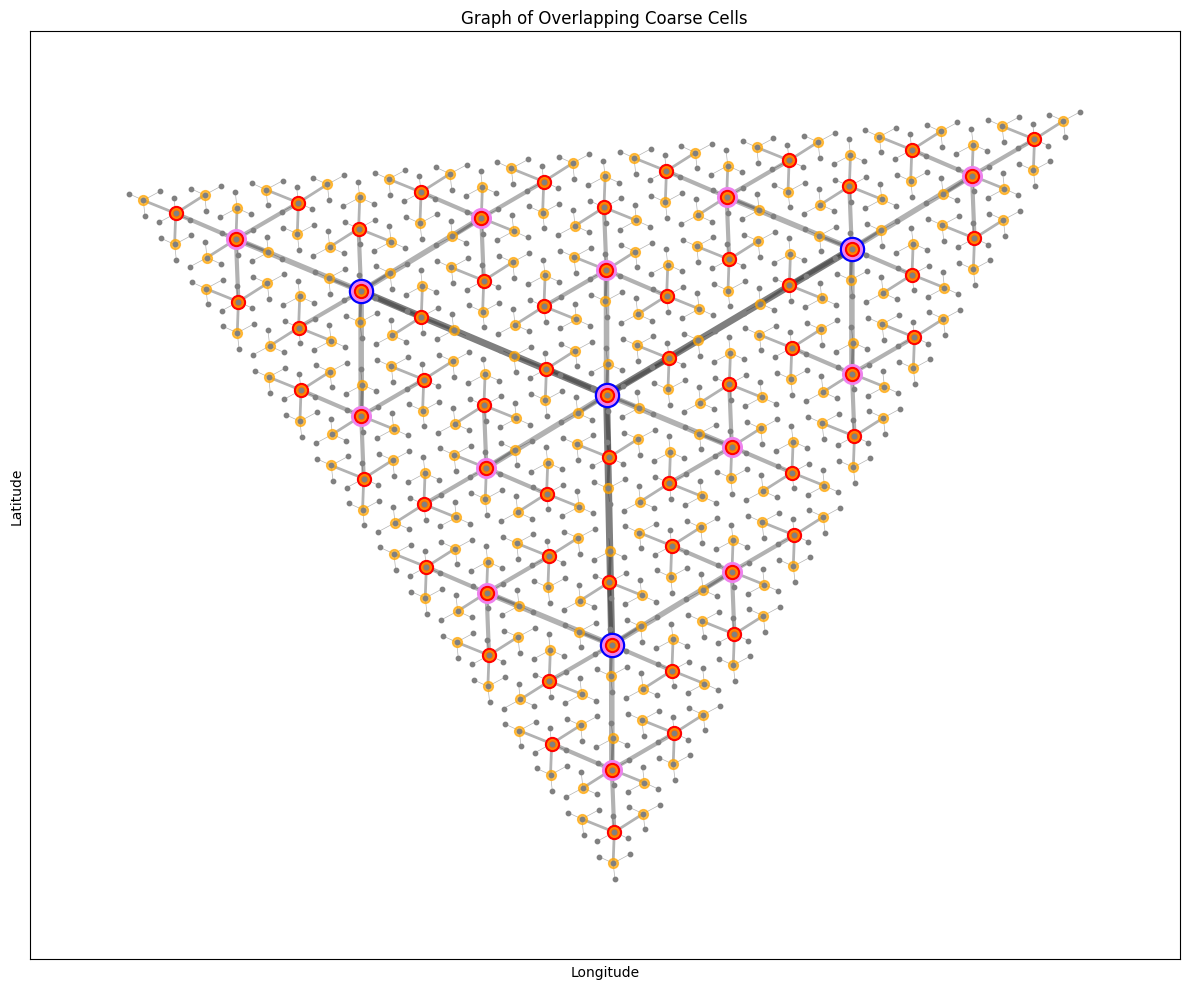

In [ ]:
# Visualize the graph
fig, ax = plt.subplots(figsize=(12, 10))

# Draw the graph with geographic positions
nx.draw_networkx_nodes(Gcoarsestx, pos_coarsestx, node_size=300, node_color='blue', ax=ax)
nx.draw_networkx_edges(Gcoarsestx, pos_coarsestx, alpha=0.5, width=5, ax=ax)
nx.draw_networkx_nodes(Gcoarsest, pos_coarsest, node_size=200, node_color='violet', ax=ax)
nx.draw_networkx_edges(Gcoarsest, pos_coarsest, alpha=0.3, width=4, ax=ax)
nx.draw_networkx_nodes(Gcoarser, pos_coarser, node_size=100, node_color='red', ax=ax)
nx.draw_networkx_edges(Gcoarser, pos_coarser, alpha=0.3, width=3, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='orange', alpha=0.7, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=2, ax=ax)
nx.draw_networkx_nodes(Gorg, orig_pos, node_size=10, node_color='grey', ax=ax)
nx.draw_networkx_edges(Gorg, orig_pos, alpha=0.3, width=0.5, ax=ax)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Graph of Overlapping Coarse Cells')
plt.tight_layout()
plt.show()

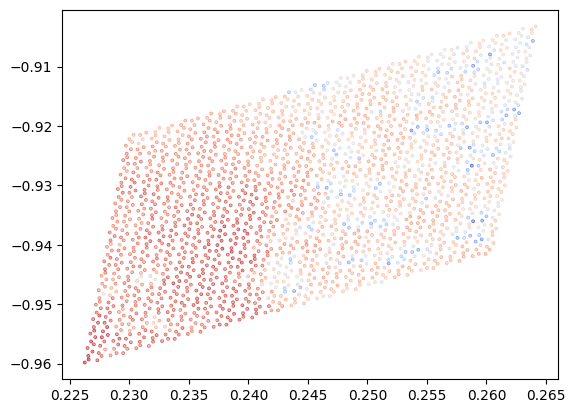

In [139]:
scatter = plt.scatter(grid_sel.clat.isel(cell=cell).values, grid_sel.clon.isel(cell=cell).values, c=mean, s=0.5, cmap='coolwarm', 
                    vmin=min(mean), vmax=max(mean), 
                    alpha=0.8, linewidths=2)